In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

os.makedirs("results", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [2]:
val_root = "./chest_xray_split/val"
test_root = "./chest_xray/chest_xray/test"

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

batch_size = 64

val_dataset = ImageFolder(val_root, transform=eval_transform)
test_dataset = ImageFolder(test_root, transform=eval_transform)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class_names = val_dataset.classes
num_classes = len(class_names)

print("类别:", class_names)
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

类别: ['NORMAL', 'PNEUMONIA']
Val: 1043
Test: 624


In [3]:
class Cecilia(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64 * 56 * 56, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.model(x)

In [4]:
def load_cecilia():
    model = Cecilia()
    model.load_state_dict(torch.load("checkpoints/best_cecilia.pth", map_location=device))
    return model.to(device).eval()


def load_vgg16():
    model = models.vgg16(weights=None)
    model.classifier[6] = nn.Linear(4096, num_classes)
    model.load_state_dict(torch.load("checkpoints/best_vgg16.pth", map_location=device))
    return model.to(device).eval()


def load_resnet18():
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.load_state_dict(torch.load("checkpoints/best_resnet18.pth", map_location=device))
    return model.to(device).eval()


models_dict = {
    "Cecilia": load_cecilia(),
    "VGG16": load_vgg16(),
    "ResNet18": load_resnet18(),
}

In [5]:
def collect_predictions(model, loader):
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


def evaluate_one_model(model_name, model, loader, split_name):
    y_true, y_pred, y_prob = collect_predictions(model, loader)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)

    cm = confusion_matrix(y_true, y_pred)

    metrics = {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro"),
        "recall_macro": recall_score(y_true, y_pred, average="macro"),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "normal_recall": recall_score(y_true, y_pred, pos_label=0),
        "pneumonia_recall": recall_score(y_true, y_pred, pos_label=1),
        "auc": roc_auc,
        "ap": ap,
    }

    return {
        "metrics": metrics,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "fpr": fpr,
        "tpr": tpr,
        "precision_curve": precision_curve,
        "recall_curve": recall_curve,
        "cm": cm,
    }

In [6]:
results = {}

for model_name, model in models_dict.items():
    print(f"\n===== {model_name} =====")

    results[(model_name, "val")] = evaluate_one_model(model_name, model, val_loader, "val")
    results[(model_name, "test")] = evaluate_one_model(model_name, model, test_loader, "test")

    y_true = results[(model_name, "test")]["y_true"]
    y_pred = results[(model_name, "test")]["y_pred"]

    print("\n--- Test Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))


===== Cecilia =====

--- Test Classification Report ---
              precision    recall  f1-score   support

      NORMAL     0.9702    0.6966    0.8109       234
   PNEUMONIA     0.8443    0.9872    0.9102       390

    accuracy                         0.8782       624
   macro avg     0.9073    0.8419    0.8606       624
weighted avg     0.8915    0.8782    0.8730       624

Confusion Matrix:
[[163  71]
 [  5 385]]

===== VGG16 =====

--- Test Classification Report ---
              precision    recall  f1-score   support

      NORMAL     0.9928    0.5855    0.7366       234
   PNEUMONIA     0.8004    0.9974    0.8881       390

    accuracy                         0.8429       624
   macro avg     0.8966    0.7915    0.8123       624
weighted avg     0.8725    0.8429    0.8313       624

Confusion Matrix:
[[137  97]
 [  1 389]]

===== ResNet18 =====

--- Test Classification Report ---
              precision    recall  f1-score   support

      NORMAL     0.9936    0.6624    0.

In [7]:
metrics_df = pd.DataFrame([v["metrics"] for v in results.values()])
metrics_df.to_csv("results/metrics_summary.csv", index=False)
metrics_df

,model,split,accuracy,precision_macro,recall_macro,f1_macro,normal_recall,pneumonia_recall,auc,ap
0,Cecilia,val,0.952061,0.933774,0.942111,0.937831,0.921642,0.962581,0.986996,0.994858
1,Cecilia,test,0.878205,0.907268,0.841880,0.860555,0.696581,0.987179,0.956114,0.969539
2,VGG16,val,0.978907,0.973481,0.971160,0.972313,0.955224,0.987097,0.998214,0.999390
3,VGG16,test,0.842949,0.896583,0.791453,0.812343,0.585470,0.997436,0.976660,0.985176
4,ResNet18,val,0.996165,0.994978,0.994978,0.994978,0.992537,0.997419,0.999966,0.999988
5,ResNet18,test,0.871795,0.912393,0.829915,0.850816,0.662393,0.997436,0.978791,0.981871


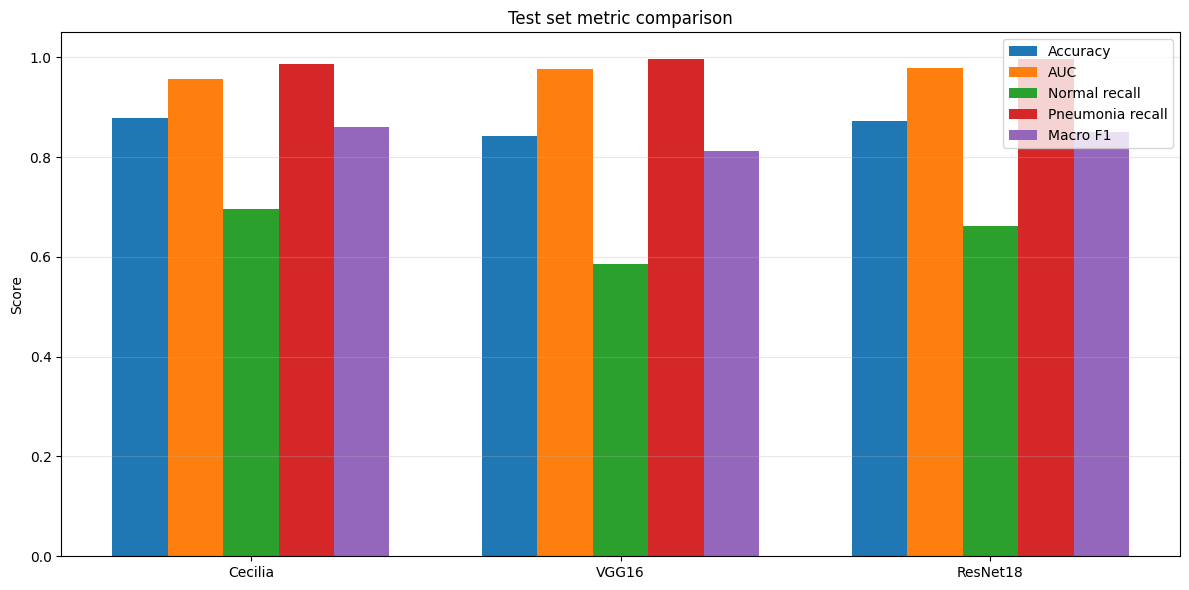

In [8]:
test_df = metrics_df[metrics_df["split"] == "test"].copy()

plot_metrics = ["accuracy", "auc", "normal_recall", "pneumonia_recall", "f1_macro"]
display_names = {
    "accuracy": "Accuracy",
    "auc": "AUC",
    "normal_recall": "Normal recall",
    "pneumonia_recall": "Pneumonia recall",
    "f1_macro": "Macro F1"
}

x = np.arange(len(test_df["model"]))
width = 0.15

plt.figure(figsize=(12, 6))

for i, metric in enumerate(plot_metrics):
    plt.bar(x + (i - 2) * width, test_df[metric], width, label=display_names[metric])

plt.xticks(x, test_df["model"])
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Test set metric comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("results/model_metrics_bar.png", dpi=300)
plt.show()

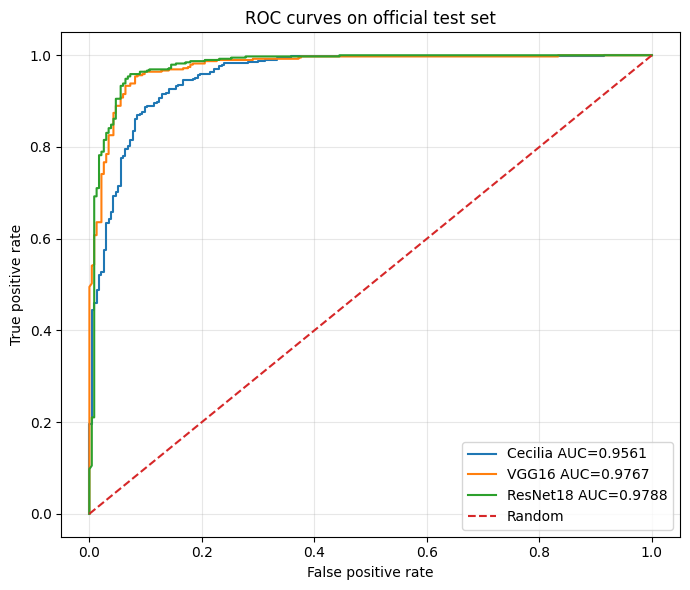

In [9]:
plt.figure(figsize=(7, 6))

for model_name in models_dict.keys():
    r = results[(model_name, "test")]
    plt.plot(r["fpr"], r["tpr"], label=f"{model_name} AUC={r['metrics']['auc']:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves on official test set")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/roc_curves.png", dpi=300)
plt.show()

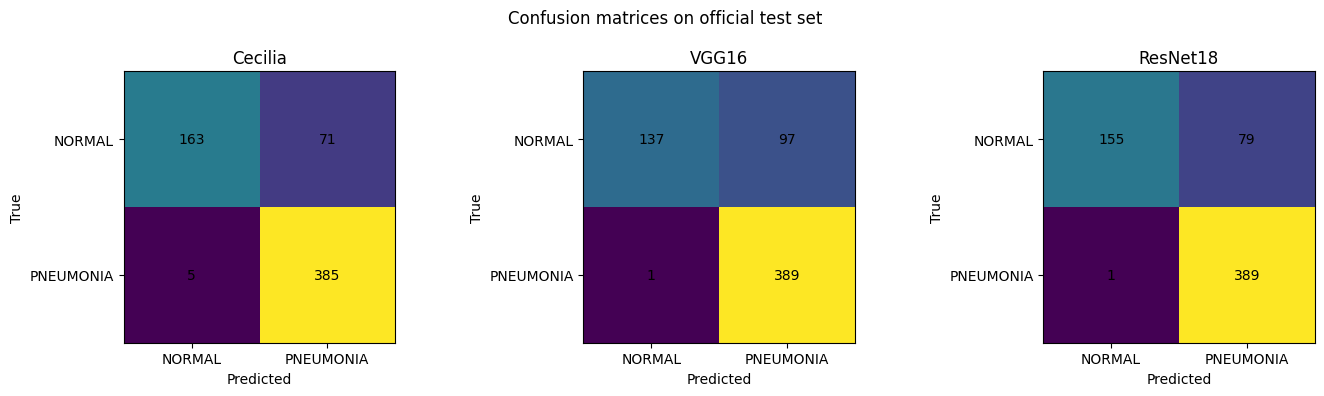

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, model_name in zip(axes, models_dict.keys()):
    cm = results[(model_name, "test")]["cm"]

    im = ax.imshow(cm)
    ax.set_title(model_name)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

fig.suptitle("Confusion matrices on official test set")
plt.tight_layout()
plt.savefig("results/confusion_matrices.png", dpi=300)
plt.show()

In [11]:
thresholds = np.arange(0.1, 0.91, 0.05)
rows = []

for model_name in models_dict.keys():
    y_true = results[(model_name, "test")]["y_true"]
    y_prob = results[(model_name, "test")]["y_prob"]

    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)

        rows.append({
            "model": model_name,
            "threshold": th,
            "accuracy": accuracy_score(y_true, y_pred),
            "normal_recall": recall_score(y_true, y_pred, pos_label=0),
            "pneumonia_recall": recall_score(y_true, y_pred, pos_label=1),
            "macro_f1": f1_score(y_true, y_pred, average="macro"),
        })

threshold_df = pd.DataFrame(rows)
threshold_df.to_csv("results/threshold_sweep.csv", index=False)
threshold_df.head()

,model,threshold,accuracy,normal_recall,pneumonia_recall,macro_f1
0,Cecilia,0.10,0.745192,0.324786,0.997436,0.659528
1,Cecilia,0.15,0.775641,0.405983,0.997436,0.711626
2,Cecilia,0.20,0.806090,0.487179,0.997436,0.759351
3,Cecilia,0.25,0.828526,0.547009,0.997436,0.792165
4,Cecilia,0.30,0.841346,0.581197,0.997436,0.810134


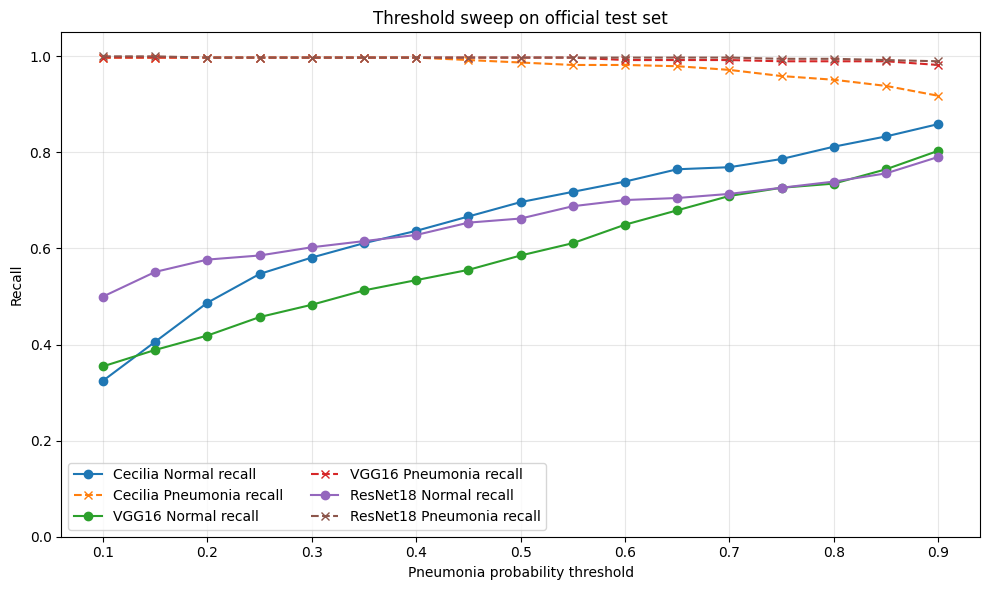

In [12]:
plt.figure(figsize=(10, 6))

for model_name in models_dict.keys():
    sub = threshold_df[threshold_df["model"] == model_name]
    plt.plot(sub["threshold"], sub["normal_recall"], marker="o", label=f"{model_name} Normal recall")
    plt.plot(sub["threshold"], sub["pneumonia_recall"], marker="x", linestyle="--", label=f"{model_name} Pneumonia recall")

plt.xlabel("Pneumonia probability threshold")
plt.ylabel("Recall")
plt.title("Threshold sweep on official test set")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.savefig("results/threshold_sweep.png", dpi=300)
plt.show()